# Data Discovery: MovieLens & TMDb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
FIG_DIR = '../results/figures'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Load Data

In [2]:
movies_df = pd.read_csv('../data/processed/movies_final.csv')
ratings_df = pd.read_csv('../data/processed/ratings_final.csv')
display(movies_df.head())
display(ratings_df.head())


,movieId,tmdbId,title,ml_genres,clean_genres,language,overview,release_year,vote_average,vote_count,popularity
0,79132,27205,Inception (2010),Action|Crime|Drama|Mystery|Other|Sci-Fi|Thriller,Action|Adventure|Mystery|Sci-Fi|Thriller,English,"Cobb, a skilled thief who commits corporate es...",2010,8.1,14075,29.108149
1,58559,155,"Dark Knight, The (2008)",Action|Crime|Drama|Other,Action|Crime|Drama|Thriller,English,Batman raises the stakes in his war on crime. ...,2008,8.3,12269,123.167259
2,72998,19995,Avatar (2009),Action|Adventure|Other|Sci-Fi,Action|Adventure|Fantasy|Sci-Fi,English,"In the 22nd century, a paraplegic Marine is di...",2009,7.2,12114,185.070892
3,89745,24428,"Avengers, The (2012)",Action|Adventure|Other|Sci-Fi,Action|Adventure|Sci-Fi,English,When an unexpected enemy emerges and threatens...,2012,7.4,12000,89.887648
4,122904,293660,Deadpool (2016),Action|Adventure|Comedy|Sci-Fi,Action|Adventure|Comedy,English,Deadpool tells the origin story of former Spec...,2016,7.4,11444,187.860492


,userId,movieId,rating
0,1,17,4.0
1,1,25,1.0
2,1,29,2.0
3,1,30,5.0
4,1,32,5.0


## 2. Rating Distribution

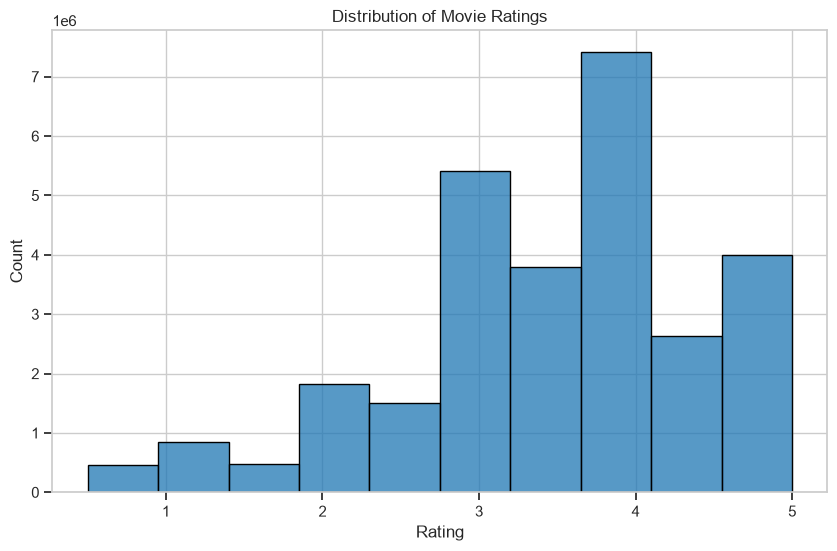

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings_df[['rating']], x='rating', bins=10, kde=False)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig(f'{FIG_DIR}/01_rating_distribution.png', bbox_inches='tight')
plt.show()


## 3. Genre Popularity

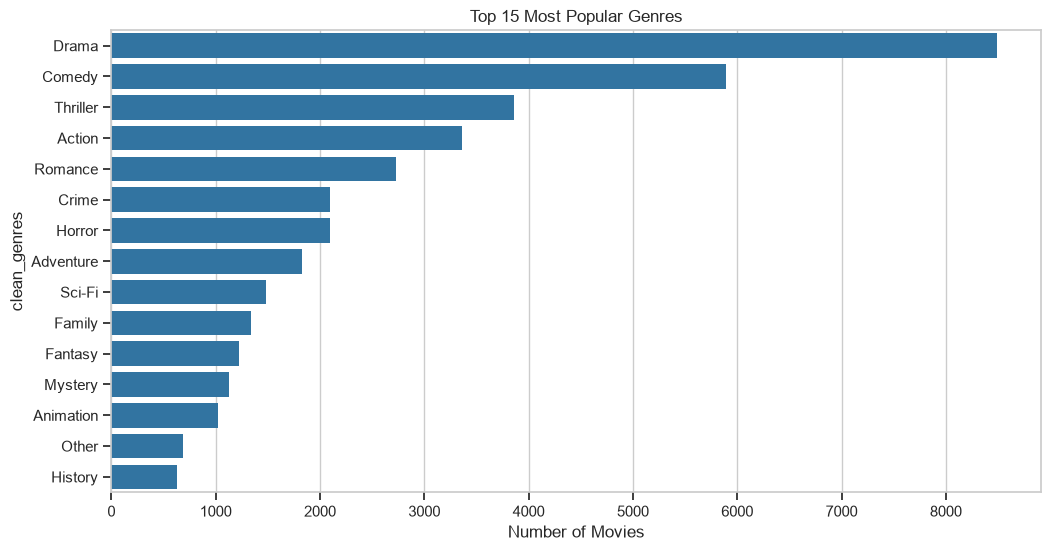

In [4]:
all_genres = movies_df['clean_genres'].str.split('|').explode()
genre_counts = all_genres.value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top 15 Most Popular Genres')
plt.xlabel('Number of Movies')
plt.savefig(f'{FIG_DIR}/02_genre_popularity.png', bbox_inches='tight')
plt.show()


## 4. Language Distribution

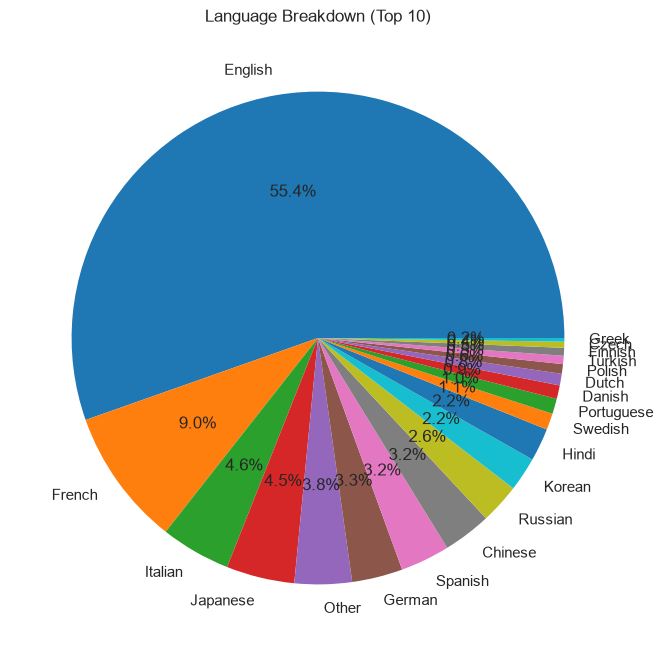

In [5]:
if 'language' in movies_df.columns:
    lang_counts = movies_df['language'].value_counts().head(20)
    plt.figure(figsize=(8, 8))
    plt.pie(lang_counts.tolist(), labels=lang_counts.index.tolist(), autopct='%1.1f%%')
    plt.title('Language Breakdown (Top 10)')
    plt.savefig(f'{FIG_DIR}/03_language_distribution.png', bbox_inches='tight')
    plt.show()